In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.stats as st

matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
palette = {'wt': 'blue', 'mutated': 'red', 'heterozygous': 'orange'}


In [3]:
adata = sc.read_h5ad('../../2_figure_CL_benchmarking/output/lhs_genotyped_adata.h5ad')
adata.obsm['genotypes'] = adata.obsm['genotypes'].replace(({0 : 'wt', 1 : 'mutated', 2 : 'heterozygous'}))
adata.obsm['predicted_genotypes'] = adata.obsm['predicted_genotypes'].replace(({0 : 'wt', 1 : 'mutated', 2 : 'heterozygous'}))

adata_dual = adata.copy()

In [4]:
adata = sc.read_h5ad('../../1_figure_CL_proof_of_concept/output/gapfill_betaine_1plex_genotyped_adata.h5ad')
adata.obsm['genotypes'] = adata.obsm['genotypes'].replace(({0 : 'wt', 1 : 'mutated', 2 : 'heterozygous'}))
adata.obsm['predicted_genotypes'] = adata.obsm['predicted_genotypes'].replace(({0 : 'wt', 1 : 'mutated', 2 : 'heterozygous'}))

adata_gap = adata[adata.obs['BC'] == 'CL3_HB_Betaine_BC001'].copy()

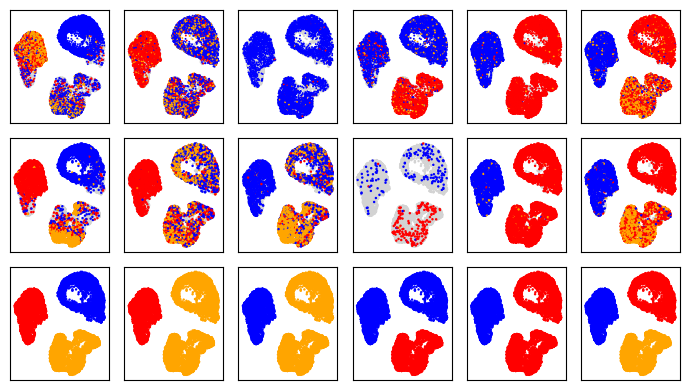

In [5]:
### Lowest accuracy for gapfill: TP53 c.742C>T, PARP9 c.1444A>G, SPN c.879C>G, JAK2 c.1849G>T
### Lowest accuracy for dual: AKAP9 c.1389G>T, MKI67 c.8158A>C

fig, axs = plt.subplots(3,6, figsize=(7,4))

for i, probe in enumerate(['MKI67 c.8158A>C','TAF1B c.1386G>T','PARP9 c.1444A>G','TP53 c.742C>T','SPN c.879C>T','JAK2 c.1849G>T']):
    adata_dual.obs['temp'] = adata_dual.obsm['genotypes'][probe].copy()
    BC_to_keep = adata_dual[adata_dual.obs['temp'].notna()].obs['BC'].unique()[0]
    sc.pl.umap(
        adata_dual[adata_dual.obs['BC'] == BC_to_keep].copy(),
        color='temp',
        frameon=True,
        title=probe,
        palette=palette,
        ax=axs[0,i],
        show=False,
        legend_loc=None
    )

    adata_gap.obs['temp'] = adata_gap.obsm['genotypes'][probe].copy()
    BC_to_keep = adata_gap[adata_gap.obs['temp'].notna()].obs['BC'].unique()[0]
    sc.pl.umap(
        adata_gap[adata_gap.obs['BC'] == BC_to_keep].copy(),
        color='temp',
        frameon=True,
        title=probe,
        palette=palette,
        ax=axs[1,i],
        show=False,
        legend_loc= None
    )

    adata_gap.obs['temp'] = adata_gap.obsm['predicted_genotypes'][probe].copy()
    BC_to_keep = adata_gap[adata_gap.obs['temp'].notna()].obs['BC'].unique()[0]
    sc.pl.umap(
        adata_gap[adata_gap.obs['BC'] == BC_to_keep].copy(),
        color='temp',
        frameon=True,
        title=probe,
        palette=palette,
        ax=axs[2,i],
        show=False,
        legend_loc= None
    )

    for row in [0,1,2]:
        axs[row,i].set_xlabel('')
        axs[row,i].set_ylabel('')
        axs[row,i].set_title('')
        
plt.tight_layout()
for ax in axs.flat:
    ax.set_rasterized(True)
plt.savefig('../plots/dual_vs_gapfill_umaps.pdf', bbox_inches='tight')
